# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive

MyDrive


In [ ]:
!ls /content/drive/MyDrive/PI_II

 Autenticacion_Carteras__Metricas_v03.ipynb
 Chanel_Parts.zip
 chanel.zip
 Ch_parts_v2
 DATASET
 DATASET.zip
'Guía Experta: Autenticación de Carteras Chanel.gdoc'
 modelo_autenticacion.h5
 modelo_autenticacion.keras
 modelo_logo_turnlock_balanceado.keras
 modelo_logo_turnlock_corregido.keras
 modelo_logo_turnlock.keras
 pipeline_autenticacion.docx
 pipeline_autenticacion_v2.docx
 Proyecto_Pipeline_COMPLETO.docx
 Proyecto_Pipeline.docx
 Proyecto_Pipeline_final.docx
 VERSION_01
 VERSION_02
 yolo_chanel.ipynb


In [ ]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PI_II/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [ ]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [ ]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [ ]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0, MobileNetV2 y ResNet50.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [10]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['genuine', 'fake']


In [11]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
    fake/bag---boy                200
   fake/bag---2.55                200

TOTAL DE IMÁGENES: 2446


### <span style="color:#800020"><b>Modelo de Partes EfficientNetB0</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB0 mediante transferencia de aprendizaje

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

model.save("/content/drive/MyDrive/PI_II/modelo_logo_turnlock_corregido.keras")

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 42s 183ms/step - accuracy: 0.6949 - loss: 0.7074 - val_accuracy: 0.6973 - val_loss: 0.5987
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6944 - loss: 0.6315 - val_accuracy: 0.7260 - val_loss: 0.5856
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7190 - loss: 0.5909 - val_accuracy: 0.7751 - val_loss: 0.5603
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7598 - loss: 0.5488 - val_accuracy: 0.7996 - val_loss: 0.5352
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7879 - loss: 0.5244 - val_accuracy: 0.8057 - val_loss: 0.5083
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8237 - loss: 0.4957 - val_accuracy: 0.8200 - val_lo

### <span style="color:#800020"><b>Modelo de Partes MobileNetV2</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura MobileNetV2 mediante transferencia de aprendizaje

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_mobile = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("Mejor Val Accuracy MobileNetV2:", max(history_mobile.history["val_accuracy"]))
print("Mejor Val Loss MobileNetV2:", min(history_mobile.history["val_loss"]))

model_mobile.save(
    "/content/drive/MyDrive/PI_II/modelo_mobilenetv2_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_mobile.pkl", "wb") as f:
    pickle.dump(history_mobile.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.5146 - loss: 0.8044 - val_accuracy: 0.4683 - val_loss: 0.7590
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5534 - loss: 0.7599 - val_accuracy: 0.5276 - val_loss: 0.7115
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5672 - loss: 0.7158 - val_accuracy: 0.6155 - val_loss: 0.6525
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6168 - loss: 0.6833 - val_accuracy: 0.6708 - val_loss: 0.6252
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6331 - loss: 0.6698 - val_accuracy: 0.6973 - val_loss: 0.5995
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6679 - loss: 0.6145 - val_accuracy: 0.7260 - val_lo

### <span style="color:#800020"><b>Modelo de Partes ResNet50</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura ResNet50 mediante transferencia de aprendizaje

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("Mejor Val Accuracy ResNet50:", max(history_resnet.history["val_accuracy"]))
print("Mejor Val Loss ResNet50:", min(history_resnet.history["val_loss"]))

model_resnet.save(
    "/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_resnet.pkl", "wb") as f:
    pickle.dump(history_resnet.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.6152 - loss: 0.7088 - val_accuracy: 0.6667 - val_loss: 0.6136
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7133 - loss: 0.5792 - val_accuracy: 0.7791 - val_loss: 0.5363
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7675 - loss: 0.4975 - val_accuracy: 0.8446 - val_loss: 0.4269
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8028 - loss: 0.4608 - val_accuracy: 0.8446 - val_loss: 0.4148
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8278 - loss: 0.4162 - val_accuracy: 0.8630 - val_loss: 0.3977
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8452 - loss: 0.3825 - val_accuracy: 0.8773 - val_los

In [28]:
from tensorflow.keras.models import load_model
import pandas as pd

model_eff = load_model("/content/drive/MyDrive/PI_II/modelo_logo_turnlock_corregido.keras")
model_mobile = load_model("/content/drive/MyDrive/PI_II/modelo_mobilenetv2_logo_turnlock.keras")
model_resnet = load_model("/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras")

loss_eff, acc_eff = model_eff.evaluate(val_ds, verbose=0)
loss_mobile, acc_mobile = model_mobile.evaluate(val_ds, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(val_ds, verbose=0)

resultados = pd.DataFrame({
    "Modelo": ["ResNet50", "EfficientNetB0", "MobileNetV2"],
    "Accuracy": [acc_resnet, acc_eff, acc_mobile],
    "Loss": [loss_resnet, loss_eff, loss_mobile]
})

resultados["Accuracy (%)"] = resultados["Accuracy"] * 100
resultados["Error (%)"] = 100 - resultados["Accuracy (%)"]

resultados = resultados.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

resultados["Ranking"] = ["🥇", "🥈", "🥉"]

display(resultados)

,Modelo,Accuracy,Loss,Accuracy (%),Error (%),Ranking
0,ResNet50,0.926380,0.227940,92.638040,7.361960,🥇
1,EfficientNetB0,0.885481,0.338831,88.548058,11.451942,🥈
2,MobileNetV2,0.828221,0.434094,82.822084,17.177916,🥉


In [29]:
print("history" in globals())
print("history_resnet" in globals())
print("history_mobile" in globals())

True
True
True


**Precisión de Entrenamiento y Validación**

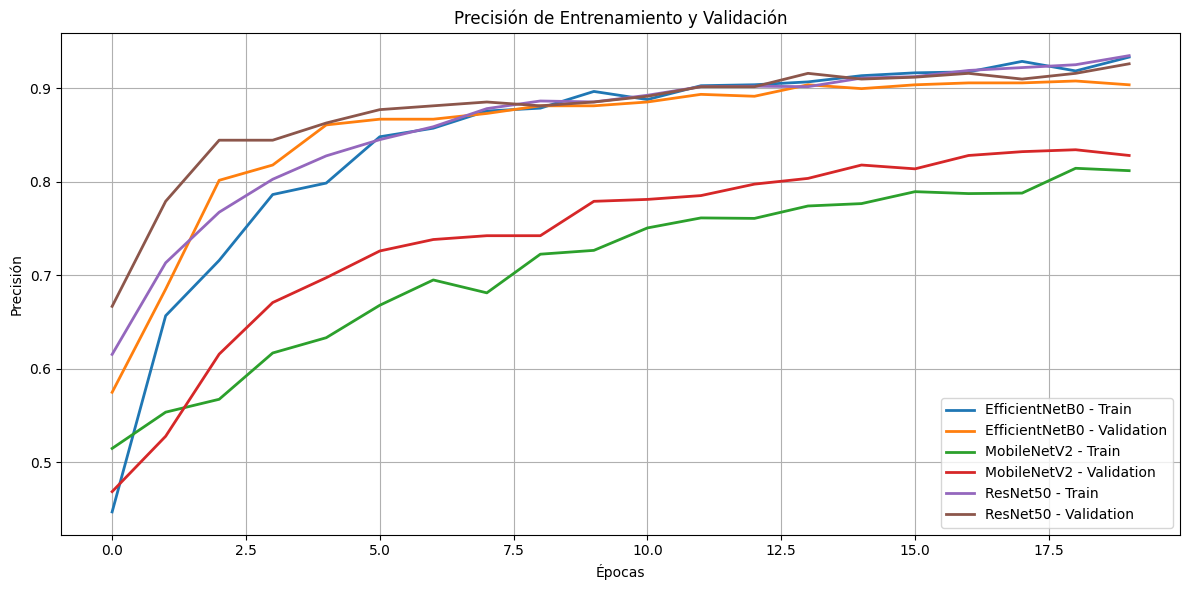

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'], label='EfficientNetB0 - Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='EfficientNetB0 - Validation', linewidth=2)

plt.plot(history_mobile.history['accuracy'], label='MobileNetV2 - Train', linewidth=2)
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2 - Validation', linewidth=2)

plt.plot(history_resnet.history['accuracy'], label='ResNet50 - Train', linewidth=2)
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50 - Validation', linewidth=2)

plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Loss de Entrenamiento vs Validación**

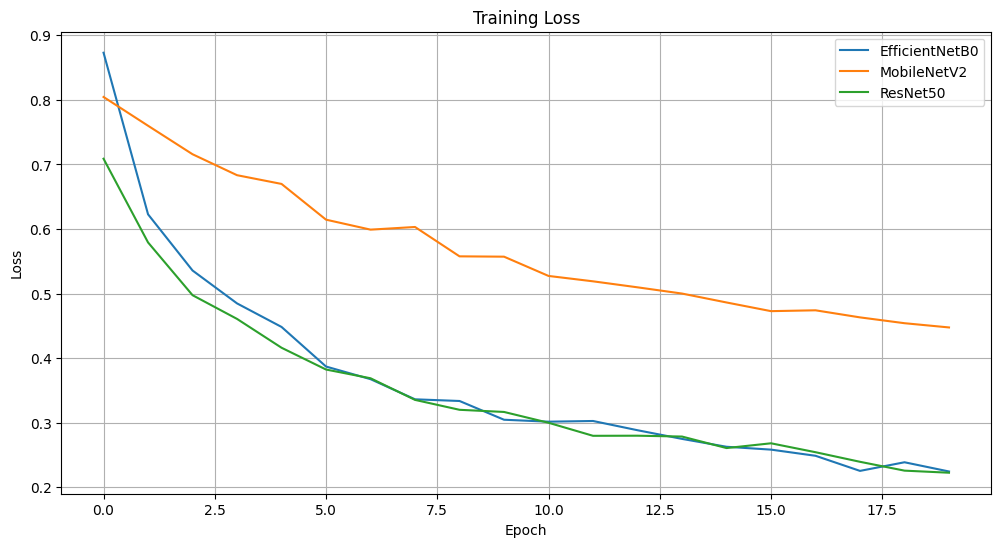

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='EfficientNetB0')
plt.plot(history_mobile.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()